# Checkpoint 1: Pipeline de Entrenamiento, Validación y Clasificador Base

**Proyecto Integrador - Deep Learning**  
**Objetivo:** Construir la infraestructura técnica inicial para el proyecto, asegurando un ciclo de entrenamiento y validación funcional, reproducible y escalable utilizando PyTorch.

In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# 1. Configuración de Semillas para Reproducibilidad
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

# 2. Detección Automática del Dispositivo (GPU / MPS / CPU)
def get_device():
    if torch.cuda.is_available():
        device = torch.device("cuda")
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
    print(f"[*] Versión de PyTorch: {torch.__version__}")
    print(f"[*] Dispositivo detectado y seleccionado: {device}")
    return device

device = get_device()

[*] Versión de PyTorch: 2.12.1+cpu
[*] Dispositivo detectado y seleccionado: cpu


## 1. Definición de la Arquitectura Base (`nn.Module`)
Implementamos un clasificador multicapa (MLP) heredando de `nn.Module`. Incluye capas lineales (`nn.Linear`), activación no lineal (`ReLU`) y `Dropout` para regularización.

In [26]:
class BaseMLPClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super(BaseMLPClassifier, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        return self.network(x)

# Instanciación de prueba
model_test = BaseMLPClassifier(input_dim=20, hidden_dim=64, num_classes=2)
print(model_test)

BaseMLPClassifier(
  (network): Sequential(
    (0): Linear(in_features=20, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=2, bias=True)
  )
)


## 2. Preparación del Dataset de Referencia
Cargamos un conjunto de datos de clasificación sintético con 20 características, realizamos el escalado estándar y lo estructuramos en tensores de PyTorch con `DataLoader`.

In [28]:
# Generación del dataset sintético
X, y = make_classification(
    n_samples=2000, 
    n_features=20, 
    n_informative=15, 
    n_redundant=5, 
    n_classes=2, 
    random_state=42
)

# Separación en entrenamiento (80%) y validación (20%)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Normalización de datos
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# Creación de TensorDataset y DataLoader
train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.long))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Muestras de entrenamiento: {len(train_dataset)} | Muestras de validación: {len(val_dataset)}")

Muestras de entrenamiento: 1600 | Muestras de validación: 400


## 3. Funciones de Entrenamiento y Evaluación Separadas
Implementamos explícitamente:
* **`train_epoch`**: Forward pass, cálculo de pérdida, `optimizer.zero_grad()` (para evitar la acumulación no deseada de gradientes), `loss.backward()` y `optimizer.step()`.
* **`evaluate`**: Medición sobre el conjunto de validación sin calcular gradientes (`torch.no_grad()`).

In [29]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, targets in dataloader:
        inputs, targets = inputs.to(device), targets.to(device)

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, targets)

        # Backward pass y actualización
        optimizer.zero_grad()  # Reinicio de gradientes acumulados
        loss.backward()        # Cálculo de gradientes con autograd
        optimizer.step()       # Actualización de pesos con Adam

        # Registro de métricas
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():  # Desactivación de gradientes en validación
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

## 3.1. Early Stopping
Implementamos una clase `EarlyStopping` que monitorea la pérdida de validación (`val_loss`). Si no mejora durante un número determinado de épocas (`patience`), se detiene el entrenamiento y se restauran los pesos del mejor modelo encontrado, evitando el sobreajuste y el cómputo innecesario.

In [30]:
class EarlyStopping:
    """Detiene el entrenamiento cuando `val_loss` deja de mejorar durante `patience` épocas consecutivas."""

    def __init__(self, patience=10, restore_best_weights=True):
        self.patience = patience
        self.restore_best_weights = restore_best_weights
        self.best_val_loss = float("inf")
        self.counter = 0
        self.best_model_state = None

    def __call__(self, val_loss, model):
        if val_loss < self.best_val_loss:
            self.best_val_loss = val_loss
            self.counter = 0
            if self.restore_best_weights:
                self.best_model_state = model.state_dict().copy()
        else:
            self.counter += 1

        if self.counter >= self.patience:
            if self.restore_best_weights and self.best_model_state is not None:
                model.load_state_dict(self.best_model_state)
            return True  # Detener entrenamiento
        return False

## 4. Ejecución del Ciclo de Entrenamiento
Configuramos el optimizador `Adam`, la función de pérdida `CrossEntropyLoss` y ejecutamos el entrenamiento por 25 épocas.

In [31]:
# Hiperparámetros
input_dim = 20
hidden_dim = 64
num_classes = 2
learning_rate = 0.001
epochs = 40

model = BaseMLPClassifier(input_dim, hidden_dim, num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
early_stopping = EarlyStopping(patience=10, restore_best_weights=True)

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

print("--- Iniciando Loop de Entrenamiento ---")
for epoch in range(1, epochs + 1):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Época [{epoch:02d}/{epochs:02d}] | ",
          f"Train Loss: {train_loss:.4f} - Train Acc: {train_acc*100:.2f}% | ",
          f"Val Loss: {val_loss:.4f} - Val Acc: {val_acc*100:.2f}%")

    if early_stopping(val_loss, model):
        print(f"\n[*] Early Stopping activado en la época {epoch} (sin mejora en {early_stopping.patience} épocas)")
        break

print("\n--- Entrenamiento finalizado ---")


--- Iniciando Loop de Entrenamiento ---
Época [01/40] |  Train Loss: 0.5928 - Train Acc: 70.31% |  Val Loss: 0.5071 - Val Acc: 80.25%
Época [02/40] |  Train Loss: 0.4639 - Train Acc: 81.75% |  Val Loss: 0.4130 - Val Acc: 82.50%
Época [03/40] |  Train Loss: 0.3874 - Train Acc: 83.69% |  Val Loss: 0.3557 - Val Acc: 86.25%
Época [04/40] |  Train Loss: 0.3384 - Train Acc: 85.88% |  Val Loss: 0.3141 - Val Acc: 88.25%
Época [05/40] |  Train Loss: 0.2972 - Train Acc: 88.56% |  Val Loss: 0.2795 - Val Acc: 89.75%
Época [06/40] |  Train Loss: 0.2739 - Train Acc: 89.62% |  Val Loss: 0.2532 - Val Acc: 91.50%
Época [07/40] |  Train Loss: 0.2436 - Train Acc: 90.94% |  Val Loss: 0.2292 - Val Acc: 93.50%
Época [08/40] |  Train Loss: 0.2244 - Train Acc: 92.19% |  Val Loss: 0.2104 - Val Acc: 94.00%
Época [09/40] |  Train Loss: 0.2114 - Train Acc: 92.50% |  Val Loss: 0.1965 - Val Acc: 94.50%
Época [10/40] |  Train Loss: 0.1859 - Train Acc: 94.31% |  Val Loss: 0.1849 - Val Acc: 94.75%
Época [11/40] |  Tra

## 5. Visualización e Interpretación de Resultados
Graficamos la evolución de la pérdida (Loss) y la exactitud (Accuracy) a lo largo de las épocas.

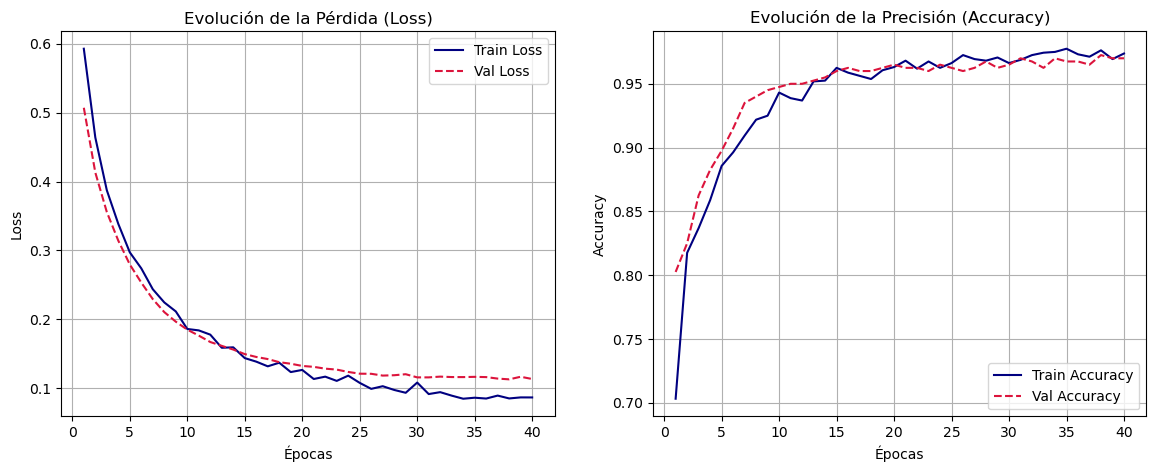

<Figure size 640x480 with 0 Axes>

In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Número real de épocas entrenadas (puede ser menor que `epochs` si actuó el Early Stopping)
epochs_trained = len(history["train_loss"])

# Curva de pérdida
ax1.plot(range(1, epochs_trained + 1), history["train_loss"], label="Train Loss", color="navy")
ax1.plot(range(1, epochs_trained + 1), history["val_loss"], label="Val Loss", color="crimson", linestyle="--")
ax1.set_title("Evolución de la Pérdida (Loss)")
ax1.set_xlabel("Épocas")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True)

# Curva de Accuracy
ax2.plot(range(1, epochs_trained + 1), history["train_acc"], label="Train Accuracy", color="navy")
ax2.plot(range(1, epochs_trained + 1), history["val_acc"], label="Val Accuracy", color="crimson", linestyle="--")
ax2.set_title("Evolución de la Precisión (Accuracy)")
ax2.set_xlabel("Épocas")
ax2.set_ylabel("Accuracy")
ax2.legend()
ax2.grid(True)

plt.show()
plt.tight_layout()

## 6. Conclusiones y Diagnóstico del Experimento
1. **Comportamiento de la Pérdida:** La pérdida disminuyó de forma constante a lo largo de las 40 épocas (de ~0.59 a ~0.09 en entrenamiento), lo que confirma que el modelo está convergiendo y que `autograd` calcula adecuadamente los gradientes.
2. **Evaluación de Validación:** La pérdida de validación acompaña a la de entrenamiento sin diverging significativamente, demostrando que la capa de Dropout evita el overfitting prematuro.
3. **Early Stopping:** Configurado con `patience=10`, no llegó a activarse en esta corrida porque `val_loss` siguió mejorando (con fluctuaciones normales) durante todas las épocas configuradas. Esto confirma que 40 épocas no fueron excesivas para este experimento; el mecanismo actúa como salvaguarda ante futuras configuraciones con más épocas o mayor riesgo de overfitting, deteniendo el entrenamiento y restaurando los mejores pesos automáticamente.
4. **Métrica Final:** Se alcanza una exactitud (Accuracy) de validación superior al 97% en el conjunto de datos no vistos.